# Retail Data Wrangling and Analytics

In [4]:
# Import modules 
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Load Data from PSQL into DataFrame

**Setup Docker Containers**

![](https://i.imgur.com/VQrBVBk.jpg)

```
#make sure you have both Jupyter and PSQL docker container running
docker ps

#Attach a bridge network to both containers so they can communicate with each other
docker network create jarvis-net
#this command works on running containers
docker network connect jarvis-net jarvis-jupyter
docker network connect jarvis-net jarvis-psql

#verify both containers are attached to the jarvis-net
docker network inspect trading-net

#Note: instead of using `localhost`, you should use container names as hostnames.
```

**Data Preperation**

- Use [pandas.read_sql](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_sql.html) api to load the PSQL retail table into a Pandas DataFrame

![](https://i.imgur.com/AmkAP63.jpg)

- Get familair with the transaction date with `df.head()`, `df.sample(10)`, `df.info()`, `df.describe()`, etc..



In [3]:
#install psql "driver"
!pip3 install psycopg2-binary

     |████████████████████████████████| 3.0 MB 7.8 MB/s eta 0:00:01


In [5]:
#Write your code in one or more cells (please remove this line from your notebook)
import psycopg2

conn = psycopg2.connect(
    dbname="postgres",
    user="postgres",
    password="password",
    host="jrvs-psql",
    port="5432"
)

retail_df = pd.read_sql("SELECT * FROM retail", conn)

conn.close()

In [6]:
retail_df.info()
retail_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   invoice_no    1067371 non-null  object        
 1   stock_code    1067371 non-null  object        
 2   description   1062989 non-null  object        
 3   quantity      1067371 non-null  int64         
 4   invoice_date  1067371 non-null  datetime64[ns]
 5   unit_price    1067371 non-null  float64       
 6   customer_id   824364 non-null   float64       
 7   country       1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


,quantity,unit_price,customer_id
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359440e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


# Load CSV into Dataframe
Alternatively, the LGS IT team also dumped the transactional data into a [CSV file](https://raw.githubusercontent.com/jarviscanada/jarvis_data_eng_demo/feature/data/python_data_wrangling/data/online_retail_II.csv). However, the CSV header (column names) doesn't follow the snakecase or camelcase naming convention (e.g. `Customer ID` instead of `customer_id` or `CustomerID`). As a result, you will need to use Pandas to clean up the data before doing any analytics. In addition, unlike the PSQL scheme, CSV files do not have data types associated. Therefore, you will need to cast/convert certain columns into correct data types (e.g. DateTime, numbers, etc..)

**Data Preparation**

In [5]:
retail_df = pd.read_csv(
    "online_retail_II.csv"
)
retail_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
#cleaning code
retail_df.rename(columns={"Customer ID": "CustomerID"}, inplace=True)
retail_df['Amount'] = retail_df['Quantity'] * retail_df['Price']
retail_df["InvoiceDate"] = pd.to_datetime(retail_df["InvoiceDate"],format="%Y-%m-%d %H:%M:%S")

In [7]:
retail_df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
CustomerID            float64
Country                object
Amount                float64
dtype: object

# Total Invoice Amount Distribution

In [8]:
# Write your code in one or more cells (please remove this line from your notebook)
print(retail_df.groupby("Invoice")["Price"].sum())

Invoice
489434      32.65
489435      10.50
489436      70.88
489437      83.45
489438      44.05
            ...  
C581484      2.08
C581490      2.78
C581499    224.69
C581568     10.95
C581569      2.50
Name: Price, Length: 53628, dtype: float64


Minimum:0.00
Mean:20.13
Median:9.96
Mode:15.00
Maximum:168469.60



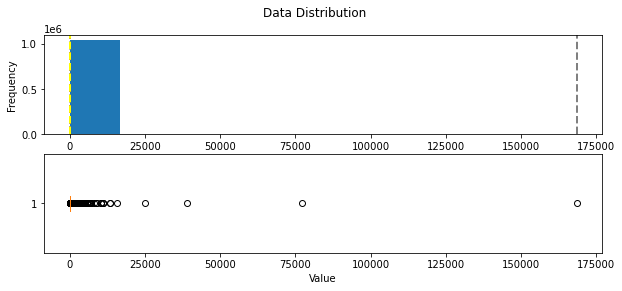

In [9]:
def show_distribution(var_data):
    from matplotlib import pyplot as plt

    # Get statistics
    min_val = var_data.min()
    max_val = var_data.max()
    mean_val = var_data.mean()
    med_val = var_data.median()
    mod_val = var_data.mode()[0]

    print('Minimum:{:.2f}\nMean:{:.2f}\nMedian:{:.2f}\nMode:{:.2f}\nMaximum:{:.2f}\n'.format(min_val,
                                                                                            mean_val,
                                                                                            med_val,
                                                                                            mod_val,
                                                                                            max_val))

    # Create a figure for 2 subplots (2 rows, 1 column)
    fig, ax = plt.subplots(2, 1, figsize = (10,4))

    # Plot the histogram   
    ax[0].hist(var_data)
    ax[0].set_ylabel('Frequency')

    # Add lines for the mean, median, and mode
    ax[0].axvline(x=min_val, color = 'gray', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=mean_val, color = 'cyan', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=med_val, color = 'red', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=mod_val, color = 'yellow', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=max_val, color = 'gray', linestyle='dashed', linewidth = 2)

    # Plot the boxplot   
    ax[1].boxplot(var_data, vert=False)
    ax[1].set_xlabel('Value')
    
        # Add a title to the Figure
    fig.suptitle('Data Distribution')

    # Show the figure
    fig.show()

# Get the variable to examine
col = retail_df['Amount'][retail_df['Amount'] > 0]
retail_df2 = pd.DataFrame(col)
# Call the function
show_distribution(col)

Minimum:0.00
Mean:9.05
Median:7.62
Mode:15.00
Maximum:24.96



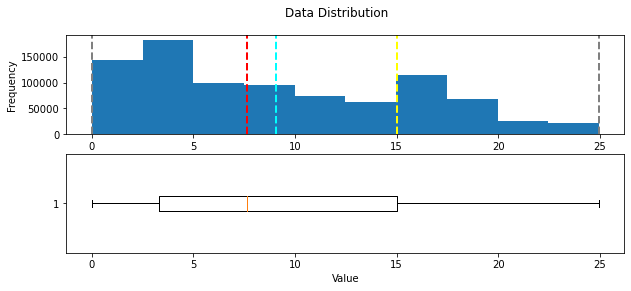

In [10]:
q01 = retail_df2['Amount'].quantile(0.85)
col = retail_df2[retail_df2.Amount <= q01]['Amount']
show_distribution(col)

# Monthly Placed and Canceled Orders

In [32]:
#removing cancelled orders
retail_df['YYYYMM'] = retail_df['InvoiceDate'].dt.year * 100 + retail_df['InvoiceDate'].dt.month
cancelled = retail_df[retail_df["Invoice"].str.startswith("C")]
cancelled["Invoice_clean"] = cancelled["Invoice"].str[1:]
to_remove = set(zip(cancelled["Invoice_clean"], cancelled["YYYYMM"]))
retail_df["key"] = list(zip(retail_df["Invoice"], retail_df["YYYYMM"]))
placed_df = retail_df[~retail_df["key"].isin(to_remove)]
placed_df = placed_df[~placed_df["Invoice"].str.startswith("C")]
placed_df = placed_df.drop(columns=["key"])

<ipython-input-32-4bc4930a99ef>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cancelled["Invoice_clean"] = cancelled["Invoice"].str[1:]


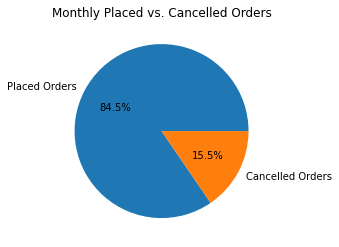

In [33]:
pie_data = {
    "Placed Orders"   : placed_df['Invoice'].nunique(),
    "Cancelled Orders": cancelled['Invoice'].nunique()
}

import matplotlib.pyplot as plt

plt.pie(
    pie_data.values(),
    labels=pie_data.keys(),
    autopct="%1.1f%%"
)

plt.title("Monthly Placed vs. Cancelled Orders")
plt.show()

# Monthly Sales

<AxesSubplot:xlabel='YYYYMM'>

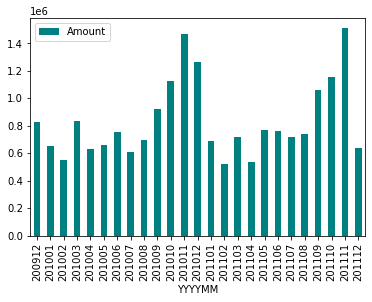

In [34]:
month_sales = placed_df.groupby('YYYYMM')['Amount'].sum().reset_index()
month_sales.plot.bar(x='YYYYMM', y='Amount', color='teal', figsize=(6,4))

# Monthly Sales Growth


In [35]:
month_sales['sales_growth_%'] = (month_sales['Amount'] - month_sales['Amount'].shift(1))/month_sales['Amount'] * 100.0
month_sales["YYYYMM"] = pd.to_datetime(month_sales["YYYYMM"], format="%Y%m")
month_sales = month_sales.sort_values('YYYYMM')

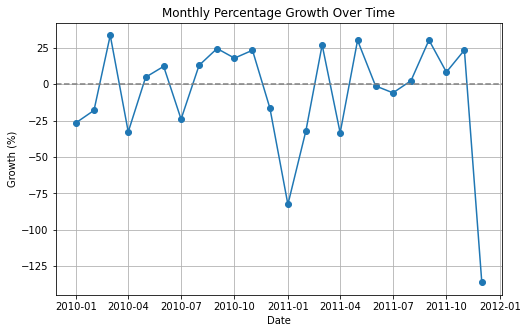

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(month_sales["YYYYMM"], month_sales["sales_growth_%"], marker='o')

plt.title("Monthly Percentage Growth Over Time")
plt.xlabel("Date")
plt.ylabel("Growth (%)")

plt.axhline(0, linestyle="--", color="gray")  # reference line at 0%
plt.grid(True)

plt.show()

# Monthly Active Users

In [37]:
active_df = retail_df.groupby('YYYYMM')['CustomerID'].nunique().reset_index()

<AxesSubplot:xlabel='YYYYMM'>

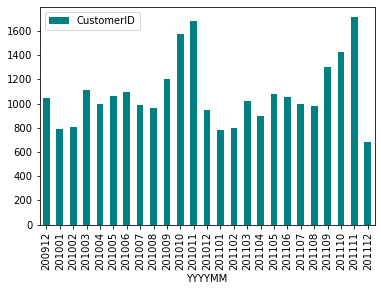

In [38]:
active_df.plot.bar(x='YYYYMM', y='CustomerID', color='teal', figsize=(6,4))

# New and Existing Users



In [39]:
first_purchase = retail_df.groupby("CustomerID")["YYYYMM"].min().reset_index()
first_purchase.columns = ["CustomerID", "FirstPurchaseMonth"]
df = retail_df.merge(first_purchase, on="CustomerID", how="left")
df["UserType"] = df.apply(
    lambda x: "New" if x["YYYYMM"] == x["FirstPurchaseMonth"] else "Existing",
    axis=1
)
user_summary = df.groupby(["YYYYMM", "UserType"])["CustomerID"].nunique().reset_index()

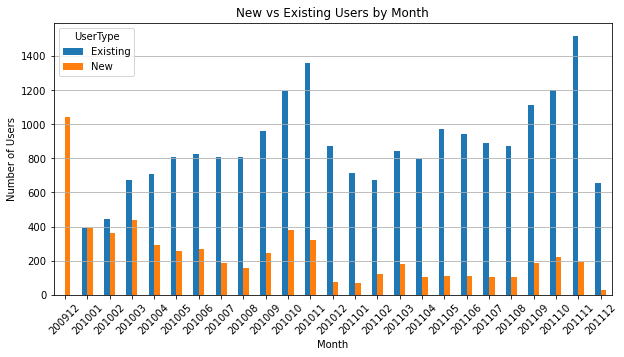

In [40]:
plot_df = user_summary.pivot(index="YYYYMM", columns="UserType", values="CustomerID").fillna(0)
plot_df = plot_df.sort_index()
import matplotlib.pyplot as plt

plot_df.plot(kind="bar", figsize=(10,5))

plt.title("New vs Existing Users by Month")
plt.xlabel("Month")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

## Finding RFM

RFM is a method used for analyzing customer value. It is commonly used in database marketing and direct marketing and has received particular attention in the retail and professional services industries. ([wikipedia](https://en.wikipedia.org/wiki/RFM_(market_research)))

Optional Reading: [Making Your Database Pay Off Using Recency Frequency and Monetary Analysis](http://www.dbmarketing.com/2010/03/making-your-database-pay-off-using-recency-frequency-and-monetary-analysis/)


RFM stands for three dimensions:

- Recency – How recently did the customer purchase?

- Frequency – How often do they purchase?

- Monetary Value – How much do they spend?

Note: To simplify the problem, let's keep all placed and canceled orders.


**Sample RFM table**

![](https://i.imgur.com/sXFIg6u.jpg)

In [42]:
# finding Recency and Monetary values.
df_x = placed_df.groupby('CustomerID').agg({'Amount': lambda x: x.sum(), #monetary value
                                        'InvoiceDate': lambda x: (pd.Timestamp.today() - x.max()).days}) #recency value
#x.max()).days; last shopping date of customers

In [43]:
df_y = placed_df.groupby(['CustomerID','Invoice']).agg({'Amount': lambda x: x.sum()})
df_z = df_y.groupby('CustomerID').agg({'Amount': lambda x: len(x)}) 
#finding the frequency value per capita

rfm_table= pd.merge(df_x,df_z, on='CustomerID')
#determination of column names
rfm_table.rename(columns= {'InvoiceDate': 'Recency',
                          'Amount_y': 'Frequency',
                          'Amount_x': 'Monetary'}, inplace= True)

In [44]:
#RFM score values 
rfm_table['RecencyScore'] = pd.qcut(rfm_table['Recency'],5,labels=[5,4,3,2,1])
rfm_table['FrequencyScore'] = pd.qcut(rfm_table['Frequency'].rank(method="first"),5,labels=[1,2,3,4,5])
rfm_table['MonetaryScore'] = pd.qcut(rfm_table['Monetary'],5,labels=[1,2,3,4,5])

In [45]:
rfm_table["RFM_SCORE"] = rfm_table['RecencyScore'].astype(str) + rfm_table['FrequencyScore'].astype(str) + rfm_table['MonetaryScore'].astype(str)

In [46]:
rfm_table.head()

,Monetary,Recency,Frequency,RecencyScore,FrequencyScore,MonetaryScore,RFM_SCORE
CustomerID,,,,,,,
12346.0,77556.46,5623,12.0,2,5,5,255
12347.0,5633.32,5300,8.0,5,4,5,545
12348.0,2019.40,5373,5.0,3,4,4,344
12349.0,4428.69,5316,4.0,5,3,5,535
12350.0,334.40,5608,1.0,2,1,2,212


# RFM Segmentation

---
**Please remove this insturction cell after you are done with coding**
RFM segmentation categorizes your customers into different segments, according to their interactions with your website, which will allow you to subsequently approach these groups in the most effective way. In this article, we will show you how to make an RFM segmentation based on an RFM score combining all three RFM parameters together and allowing you to divide your customers into 11 different segments. 

- [RFM Segmentation business cases](https://docs.exponea.com/docs/rfm-segmentation-business-use)

- [RFM Segmentation Guide](https://docs.exponea.com/docs/rfm-segmentation-business-use)

As you can see, computing RFM segmentation requires extensive domain knowledge in marketing which is out of the scope in this project. In practice, you will work with BA/DA to figure out how to compute RFM segments. To simplify this project, a [sample RFM segmentation Notebook](https://github.com/jarviscanada/jarvis_data_eng_demo/blob/feature/data/python_data_wrangling/ipynb/customer-segmentation-with-rfm-score.ipynb) is provided. You are responsible to understand everything from that Notebook and then integrate it into yours. 

- Download the [sample notebook](https://github.com/jarviscanada/jarvis_data_eng_demo/blob/feature/data/python_data_wrangling/ipynb/customer-segmentation-with-rfm-score.ipynb) and import to your Jupyter Notebook or VSCode
- Run the notebook and understand all cells
- Read the remark section at the end of the notebook. You will need this information when writing the README file
- Integrate the RFM segmentation calculation into your notebook

---

In [48]:
seg_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At Risk',
    r'[1-2]5': 'Can\'t Lose',
    r'3[1-2]': 'About to Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}

In [49]:
#creation of segment variable
rfm_table['Segment'] = rfm_table['RecencyScore'].astype(str) + rfm_table['FrequencyScore'].astype(str)
rfm_table['Segment'] = rfm_table['Segment'].replace(seg_map, regex=True)

In [51]:
rfm_table.head()

,Monetary,Recency,Frequency,RecencyScore,FrequencyScore,MonetaryScore,RFM_SCORE,Segment
CustomerID,,,,,,,,
12346.0,77556.46,5623,12.0,2,5,5,255,Can't Lose
12347.0,5633.32,5300,8.0,5,4,5,545,Champions
12348.0,2019.40,5373,5.0,3,4,4,344,Loyal Customers
12349.0,4428.69,5316,4.0,5,3,5,535,Potential Loyalists
12350.0,334.40,5608,1.0,2,1,2,212,Hibernating


In [52]:
rfm_table[["Segment", "Recency","Frequency","Monetary"]].groupby("Segment").agg(["mean","count"])

Recency        Frequency            Monetary      
                            mean count       mean count          mean count
Segment                                                                    
About to Sleep       5404.490956   387   1.359173   387    532.018096   387
At Risk              5670.942667   750   3.904000   750   1383.596253   750
Can't Lose           5628.802817    71  15.929577    71   8355.677634    71
Champions            5306.250000   852  19.217136   852  10795.520581   852
Hibernating          5757.282808  1524   1.251969  1524    437.388381  1524
Loyal Customers      5365.306016  1147   9.803836  1147   4199.728592  1147
Need Attention       5411.400000   270   3.151852   270   1280.262926   270
New Customers        5308.368421    57   1.000000    57    350.007719    57
Potential Loyalists  5323.297335   713   2.589060   713   1155.427281   713
Promising            5336.281818   110   1.000000   110    324.497000   110